# Reference Card Extraction

This notebook now explores the reusable extraction code in `src/uno_vision/data/reference_cards.py`.
The heavy lifting lives in the package; the cells here focus on picking inputs, running the extractor, and visualizing the generated assets.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from uno_vision.data.reference_cards import _reference_binary_mask, extract_reference_card_assets
from uno_vision.paths import REFERENCE_CARDS_DIR, REFERENCE_IMAGES_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference images: {REFERENCE_IMAGES_DIR}")
print(f"Processed outputs: {REFERENCE_CARDS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Reference images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\reference_images
Processed outputs: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards


In [2]:
# ── Image selection ──────────────────────────────────────────────────────────
# Map each reference image to its expected card count.
image_components = {
    "L1000765": 12,
    "L1000766": 12,
    "L1000767": 14,
    "L1000768": 16,
}

# None → process every entry above; or restrict to a subset, e.g. ["L1000768"]
images_to_process = None

# Which image to use for the single-image preview cells (mask viz + crop grid).
preview_image_name = "L1000768"

# ── Hyperparameters ──────────────────────────────────────────────────────────
# Edit values here; all cells below pick them up automatically.

# --- _reference_binary_mask (all kernel sizes are scaled internally to image resolution) ---
canny_blur_size = 5    # Gaussian blur before Canny (odd)
canny_low = 30         # Canny lower hysteresis threshold
canny_high = 100       # Canny upper hysteresis threshold
blob_close_size = 40   # morphological close to merge edge blobs into card regions
blur_after = 33        # final smoothing blur (odd)

# --- extract_reference_card_assets ---
min_area_abs = 2500    # minimum component area in pixels (at 4000px reference scale)
min_area_frac = 0.002  # minimum component area as fraction of image area
close_size = 21        # closing kernel to merge nearby blobs
open_size = 7          # opening kernel to remove thin noise
min_ar = 0.3           # minimum bounding-box aspect ratio w/h (portrait cards ~0.65)
max_ar = 2.0           # maximum bounding-box aspect ratio w/h

In [3]:
image_path = REFERENCE_IMAGES_DIR / f"{preview_image_name}.jpg"
gray = np.array(Image.open(image_path).convert("L"))
color_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
edges, binary = _reference_binary_mask(
    gray,
    canny_blur_size=canny_blur_size,
    canny_low=canny_low,
    canny_high=canny_high,
    blob_close_size=blob_close_size,
    blur_after=blur_after,
)

print(f"Image: {image_path}")
print(f"Gray shape: {gray.shape}")

Image: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\reference_images\L1000768.jpg
Gray shape: (2662, 4000)


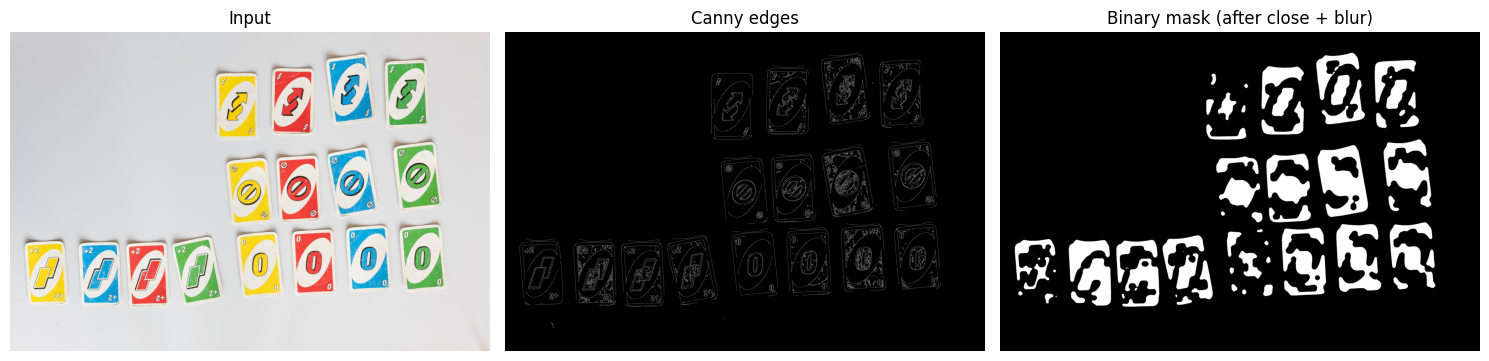

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny edges")
axes[1].axis("off")

axes[2].imshow(binary, cmap="gray")
axes[2].set_title("Binary mask (after close + blur)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
selected = list(image_components.keys()) if images_to_process is None else images_to_process

extraction_kwargs = dict(
    canny_blur_size=canny_blur_size,
    canny_low=canny_low,
    canny_high=canny_high,
    blob_close_size=blob_close_size,
    blur_after=blur_after,
    min_area_abs=min_area_abs,
    min_area_frac=min_area_frac,
    close_size=close_size,
    open_size=open_size,
    min_ar=min_ar,
    max_ar=max_ar,
)

results: dict[str, object] = {}
for name in selected:
    n = image_components[name]
    r = extract_reference_card_assets(image_name=name, num_components=n, **extraction_kwargs)
    results[name] = r
    print(f"{name}: {len(r.components)} components, {len(r.masks)} masks, {len(r.crops)} crops")

L1000765: 12 components, 12 masks, 12 crops
L1000766: 12 components, 12 masks, 12 crops
L1000767: 14 components, 14 masks, 14 crops
L1000768: 16 components, 16 masks, 16 crops


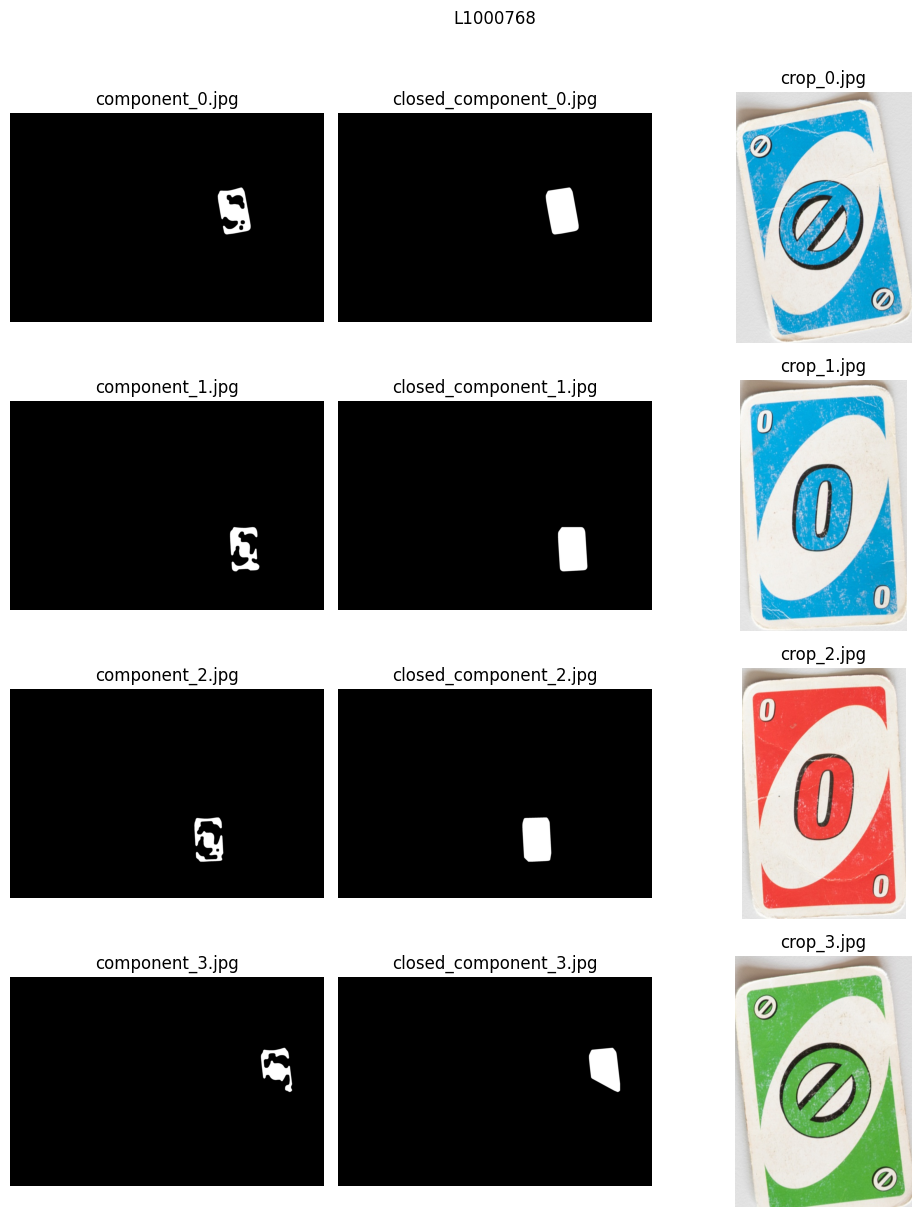

In [6]:
if preview_image_name not in results:
    raise KeyError(f"{preview_image_name!r} was not in images_to_process; add it or change preview_image_name.")

result = results[preview_image_name]
preview_rows = list(zip(result.components[:4], result.masks[:4], result.crops[:4]))
if not preview_rows:
    raise RuntimeError("No reference-card assets were generated.")

fig, axes = plt.subplots(len(preview_rows), 3, figsize=(10, 3 * len(preview_rows)))
axes = np.atleast_2d(axes)

for row_idx, (component_path, mask_path, crop_path) in enumerate(preview_rows):
    component = cv2.imread(str(component_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    crop = cv2.cvtColor(cv2.imread(str(crop_path), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    axes[row_idx, 0].imshow(component, cmap="gray")
    axes[row_idx, 0].set_title(component_path.name)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask, cmap="gray")
    axes[row_idx, 1].set_title(mask_path.name)
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(crop)
    axes[row_idx, 2].set_title(crop_path.name)
    axes[row_idx, 2].axis("off")

plt.suptitle(preview_image_name, y=1.01)
plt.tight_layout()
plt.show()